# QAOA Algorithm Exploration

This notebook documents how I approached learning QAOA by building a simple example, focusing on understanding the mechanics, where I got stuck, and how it connects to problems I’m already familiar with.

## Goal <a id="goal"></a>

Implement a simple QAOA circuit for a Max-Cut problem to understand how quantum circuits are used in optimization. I approached this from a data science, materials science and engineering simulation background, so analogies to simulation pipelines and connections to deep learning appear throughout to map familiar concepts to a new framework.

## Table of Contents

1. [Goal](#goal)
2. [Problem Setup](#problem-setup)
3. [Step 1: Creating the Graph](#step)
4. [Step 2: Max-Cut Intuitively](#step-2)
5. [Step 3: Circuit Construction](#step-3)
   - [Initialization](i#nitialization)
   - [Cost Unitary](#cost-unitary)
   - [Mixer Unitary](#mixer-unitary)
   - [Measurement](#measurement)
6. [Step 4: Run on a Simulator](#step-4)
7. [Step 5: Interpret Results](#step-5)
8. [Step 6: Parameter Sweep](#step-6)
9. [Observations](#observations)
10. [Where I Got Stuck](#where-i-got-stuck)
11. [Next Steps](#next-steps)

## Problem Setup <a id="problem-setup"></a>

Max-Cut can be framed as assigning binary labels to nodes such that the number of edges between groups is maximized. I used a 3-node graph to keep the problem simple and interpretable.

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from collections import defaultdict

# Qiskit core: circuit building
from qiskit import QuantumCircuit

# Qiskit Aer: the classical simulator that runs quantum circuits
from qiskit_aer import AerSimulator

## Step 1. Creating the Graph <a id="step-1"></a>
I defined the graph as a 3-node triangle using NetworkX. Every node connects to every other node, giving three edges and eight possible bitstring assignments.

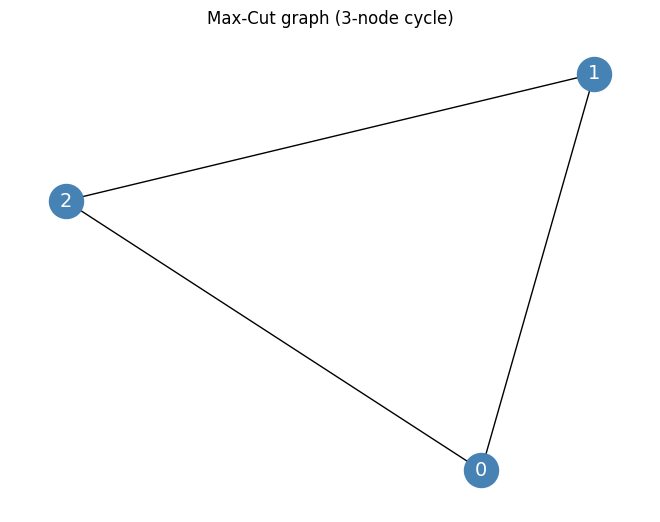

In [2]:
G = nx.Graph()
n_nodes=3
edges = [(0,1), (1,2), (0,2)]
G.add_edges_from(edges)


# Draw it
nx.draw(G, with_labels=True, node_size=600,
        node_color='steelblue', font_color='white', font_size=14)
plt.title("Max-Cut graph (3-node cycle)")
plt.show()

## Step 2. Explaining Max-Cut Intuitively <a id="step-2"></a>

Each node gets a **binary label**: 0 (group A) or 1 (group B).  
A 3-node graph needs 3 bits. The bitstring `"010"` means node 0 → group 0, node 1 → group 1, node 2 → group 0.

An edge is cut when two endpoints are in different groups. The "cut value" describes the number of edges cut.

The goal is to maximize the number of cut edges. QAOA uses a Hamiltonian operator to encode or count the number of cut edges.

In [3]:
def cut_value(bitstring, edges):
    """Count how many edges are cut by a given bitstring assignment."""
    total = 0
    for u, v in edges:
        # Edge is cut when the two endpoint bits differ
        if bitstring[u] != bitstring[v]:
            total += 1
    return total

print(f"{'Bitstring':>12}  {'Cut Value':>10}")
print("-" * 26)
best = 2
for i in range(2**n_nodes):
    # Format as zero-padded binary string of length n_nodes
    bits = format(i, f'0{n_nodes}b')
    cv = cut_value(bits, edges)
    marker = " ← best" if cv >= best else ""
    print(f"  {bits:>10}  {cv:>10}{marker}")

   Bitstring   Cut Value
--------------------------
         000           0
         001           2 ← best
         010           2 ← best
         011           2 ← best
         100           2 ← best
         101           2 ← best
         110           2 ← best
         111           0


**Expected output:** The bitstrings `001`, `010`, `011`, `100`, `101`, `110` all cut exactly **2 edges**. This is the maximum possible on a triangle (an odd cycle can never be perfectly bipartitioned). The states `000` and `111` cut 0 edges (everyone in the same group).

So QAOA's job is to assign **high probability** to those 6 good bitstrings and low probability to `000` and `111`.

## Step 3. Circuit Construction <a id="step-3"></a>

QAOA is a **variational quantum algorithm**. It works in three stages:

1. **Initialize:** make all qubit into equal superposition (every bitstring is equally probable)
2. **Evolve:** Apply two alternating unitary operations
   - **Cost Unitary or Cost Hamiltonian U_C(γ):** Encodes the optimization problem.
   - **Mixer Unitary U_B(β):** Explores alternative solutions.
3. **Measure:** Sample the circuit many times. The best solutions appear the most often.

I found it helpful to think of QAOA as an optimization loop where parameters (γ, β) are adjusted to minimize an objective function. The key difference is that the objective is evaluated through a quantum circuit rather than a classical function.

There is also a concept of p-layers. p is the number of times you repeat the cost and mixer unitary pair in sequence. At p=1 you apply U_C once and U_B once. At p=2 you apply U_C, U_B, U_C, U_B. For my example and for the sake of simplicity, p=1.

---

### Analogy - The QAOA Circuit as an Engineering Simulation Pipeline <a id="analogy"></a>

- **Initialization = Initial conditions**: Applying a Hadamard gate to every qubit creates an equal superposition of all possible bitstrings, analogous to setting a uniform initial condition across the entire domain before the simulation begins. No bias, no prior assumption about where the solution lives. The uniform superposition is the standard starting point because it gives the cost and mixer unitaries an unbiased field to work with.
- **Cost Hamiltonian = Mesh file:** Defines the geometry of the problem, nodes, connectivity, and solution landscape. Every graph edge becomes a Hamiltonian term, every Hamiltonian term becomes a gate. Problem structure and circuit structure are the same object expressed differently.
- **Mixer = Physics solver:** Applies governing rules across the domain without redesigning the geometry. Takes the phase structure imprinted by the cost unitary and redistributes amplitude toward higher cut value regions. The answer emerges from the process, not from the solver knowing the answer in advance.
- **γ and β = Boundary conditions and material properties:** Gamma controls how strongly the cost landscape is imprinted, analogous to potential well depth driving a system toward low energy configurations. Beta controls how freely amplitude flows between neighboring states, analogous to thermal energy allowing exploration and escape from metastable configurations.
- **p layers = Timesteps:** Each layer applies the physics, updates the field, and sharpens the solution. More layers improve the approximation the same way more timesteps improve simulation convergence.
- **Interpreting results = Validating simulation output:** Just as mesh quality, solver assumptions, and boundary conditions all affect whether a simulation result is trustworthy, the Hamiltonian encoding, mixer behavior, and parameter tuning all determine whether QAOA's output is meaningful.

---

### Sub-step 3a: Initialization — Hadamard  <a id="initialization"></a>

Apply a **Hadamard gate** to every qubit. The full 3-qubit state becomes an **equal superposition of all 8 bitstrings**. A perfectly flat probability distribution.

Initialization layer added (Hadamard on all qubits).


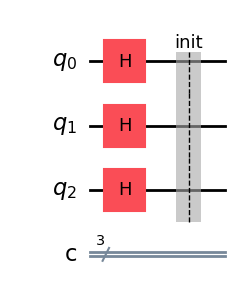

In [4]:
# ── QAOA parameters ──────────────────────────────────────────────────────────
# gamma: controls how strongly the cost function is encoded into phases
# beta:  controls how much the mixer "rotates" the state
# These are fixed for now; we'll vary them in Step 6.
gamma = np.pi / 4   # a reasonable starting value (~0.785 radians)
#gamma = 2.89     #curiosity to see result of parameter sweeping in step #6
beta  = np.pi / 8   # half of gamma, also a common heuristic starting point


# ── Build the QAOA circuit ───────────────────────────────────────────────────
qc = QuantumCircuit(n_nodes, n_nodes)   # 3 qubits, 3 classical bits

# ── Layer 0: Initialization ──────────────────────────────────────────────────
# Hadamard on every qubit → equal superposition of all 8 bitstrings
qc.h(range(n_nodes))
qc.barrier(label='init')   # visual separator in the circuit diagram


print("Initialization layer added (Hadamard on all qubits).")
qc.draw("mpl")

### Sub-step 3b: Cost Unitary U_C(γ) <a id="cost-unitary"></a>

For each edge (u, v) in the graph, we apply a **ZZ interaction** that encodes the cut condition. We essentially want the cost unitary to directly map to the Hamiltonian operator.

In Qiskit circuits, `exp(-i θ Z⊗Z)` is implemented as:
- `CNOT(u → v)` — entangles the two qubits
- `Rz(2γ)` on qubit v — applies the phase
- `CNOT(u → v)` — unentangles them

Cost unitary U_C(γ=0.7854) added for all 3 edges.


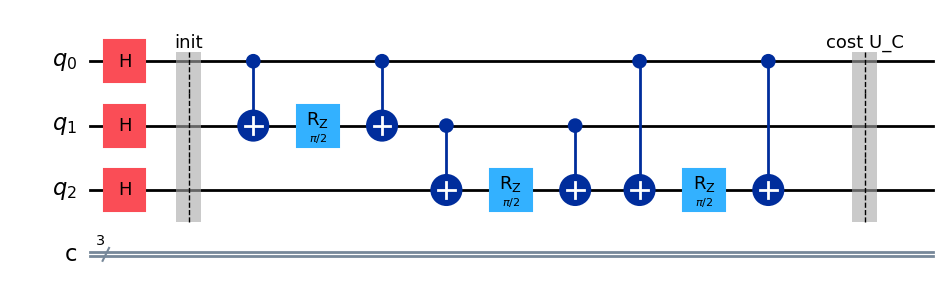

In [5]:
# ── Layer 1: Cost Unitary U_C(gamma) ────────────────────────────────────────
# For each edge (u, v): apply exp(-i * gamma * Z_u Z_v / 2)
# Circuit decomposition: CNOT → Rz(2*gamma) → CNOT

for i in edges:
    qc.cx(i[0], i[1])       # CNOT: control=u, target=v
    qc.rz(2 * gamma, i[1])         # Rz rotation on target qubit
    qc.cx(i[0], i[1])                 # CNOT again to uncompute entanglement


qc.barrier(label='cost U_C')
print(f"Cost unitary U_C(γ={gamma:.4f}) added for all {len(edges)} edges.")
qc.draw("mpl")


### Sub-step 3c: Mixer Unitary U_B(β) <a id="mixer-unitary"></a>

The mixer applies an **Rx rotation** to every qubit independently:

```
U_B(β) = exp(-i β X_j)  for each qubit j
```

In Qiskit: `Rx(2β)` on each qubit.

**Intuitively:** The X operator is the quantum NOT — it flips a qubit. Applying `exp(-iβX)` is like a partial flip: it allows the state to "leak" between bitstrings that differ by one bit. This is the quantum analog of a local search step. Without the mixer, the algorithm would be frozen in its initial superposition and the phases from U_C would never translate into different probabilities.

Mixer unitary U_B(β=0.3927) added for all 3 qubits.


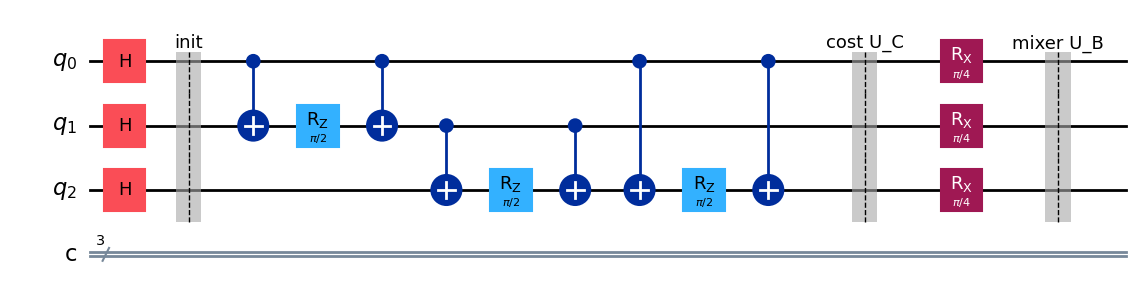

In [6]:
# ── Layer 2: Mixer Unitary U_B(beta) ────────────────────────────────────────
# Rx(2*beta) on every qubit — mixes probability amplitudes between bitstrings

for j in range(n_nodes):
    qc.rx(2 * beta, j)

qc.barrier(label='mixer U_B')
print(f"Mixer unitary U_B(β={beta:.4f}) added for all {n_nodes} qubits.")
qc.draw("mpl")

### Sub-step 3d: Measurement <a id="measurement"></a>

I now have applied one cost unitary and one mixer unitary. This is a single p-layer in my circuit. Next step is to measure all qubits into classical bits. Each measurement "collapses" the quantum state to one bitstring, with probability proportional to the squared amplitude of that state.

Measurement layer added.

Full QAOA circuit (p=1, γ=0.7854, β=0.3927):


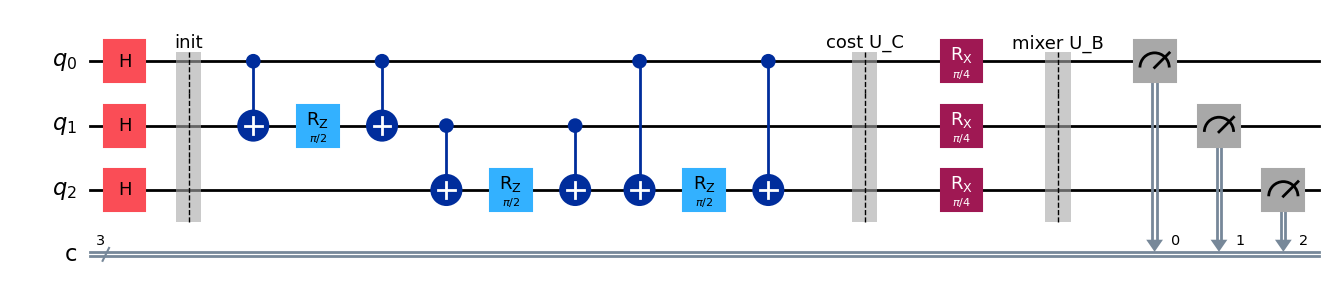

In [7]:
# ── Layer 3: Measurement ─────────────────────────────────────────────────────
# Measure all qubits; results stored in classical bits 0, 1, 2
qc.measure(range(n_nodes), range(n_nodes))

print("Measurement layer added.")
print(f"\nFull QAOA circuit (p=1, γ={gamma:.4f}, β={beta:.4f}):")
qc.draw('mpl', fold=-1, style='iqp')

**Reading the circuit diagram:**

- `q_0, q_1, q_2` — the three qubits (one per graph node)
- `H` boxes — Hadamard gates (initialization)
- `●—⊕` pairs — CNOT gates (part of the ZZ cost unitary)
- `Rz` boxes — rotation-Z gates (phase encoding for each edge)
- `Rx` boxes — rotation-X gates (mixer)
- Final boxes with meters — measurements

The barriers (dashed lines) are cosmetic separators that help me identify the three stages.

## Step 4. Run on a simulator <a id="step-4"></a>

### Why do I need a backend / simulator?

> *(This is also addressed in "Where I Got Stuck")*

A `QuantumCircuit` in Qiskit is just a description of operations. It doesn't compute anything by itself. You need a backend (either a real quantum processor or a simulator) to execute the circuit steps and return measurement results.

I used `AerSimulator`, which runs the circuit on my CPU by numerically simulating the quantum state vector. 

I ran the circuit many times ("shots") to build up a **frequency histogram** of bitstrings, the empirical approximation of the probability distribution.

Ran 4096 shots. Unique bitstrings observed: 8

Raw counts (bitstring: frequency):


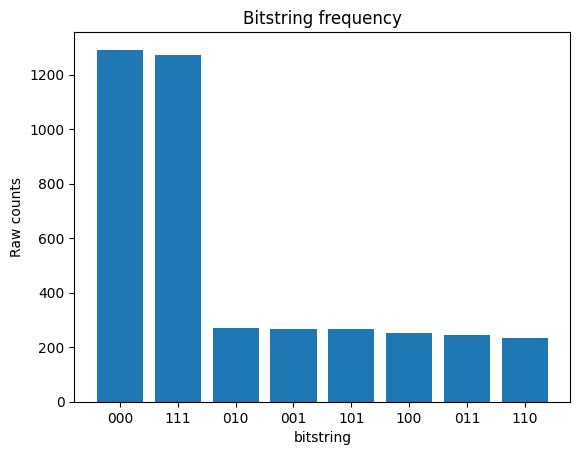

In [8]:
# ── Run on AerSimulator ───────────────────────────────────────────────────────
simulator = AerSimulator()   # classical statevector simulator

n_shots = 4096   # number of times we sample the circuit
               # more shots → smoother histogram, closer to true probabilities

# Transpile converts our abstract circuit to the gate set the backend supports
from qiskit import transpile
compiled = transpile(qc, simulator)

# Run and collect counts
job = simulator.run(compiled, shots=n_shots)
result = job.result()
counts = result.get_counts()

print(f"Ran {n_shots} shots. Unique bitstrings observed: {len(counts)}")
print("\nRaw counts (bitstring: frequency):")

#create plot
data = dict(sorted(counts.items(), key=lambda x: -x[1]))
names = list(data.keys())
values = list(data.values())
fig, ax = plt.subplots()
ax.bar(names, values)

ax.set_title('Bitstring frequency')
ax.set_xlabel('bitstring')
ax.set_ylabel('Raw counts')
plt.show()

**What to expect from the output:**  
The six good bitstrings (`001`, `010`, `011`, `100`, `101`, `110`) should appear more frequently than `000` and `111`.
With p=1, the circuit did not favor solutions that maximize the cut. Instead, it tended to assign higher probability to solutions with few or no cuts. This was unexpected at first, but it makes it clear how sensitive the output is to parameter choice at low depth.

With random γ and β, the circuit isn’t doing meaningful optimization yet, it’s just sampling a poorly shaped landscape. This reinforces that for QAOA, parameter tuning and circuit depth matter more than the basic circuit construction itself.


## Step 5: Interpret results <a id="step-5"></a>

### Reading the bitstrings

In Qiskit, the bitstring is reported with **qubit 0 on the right** (little-endian convention). So the string `"abc"` means: qubit 2 = a, qubit 1 = b, qubit 0 = c.

> **This was confusing at the first.** See "Where I Got Stuck" for a fuller explanation.

For example, bitstring "010" means: node 0 = 0 (Group A), node 1 = 1 (Group B), node 2 = 0 (Group A).

Cut edges: (0,1) ✓ different groups, (1,2) ✓ different groups, (0,2) ✗ same group → **cut value = 2**.

### What does QAOA's approximation ratio mean?

QAOA doesn't guarantee finding the *best* solution. It returns a **probability distribution** biased toward good solutions. The **approximation ratio** = (expected cut from QAOA) / (optimal cut). The highest probability bitstrings correspond to partitions that maximize the cut. For p=1 on a triangle, theoretical guarantees are weak, but in practice the bias toward good solutions will be visible in the histogram.


In [9]:
# ── Compute expected cut value from the measurement distribution ──────────────
all_bitstrings = [format(i, f'0{n_nodes}b') for i in range(2**n_nodes)]
total_shots = sum(counts.values())
expected_cut = sum(
    (cnt / total_shots) * cut_value(bs, edges)
    for bs, cnt in counts.items()
)

# Also compute the theoretical maximum and random baseline
optimal_cut = 2   # we know this from the brute-force table
random_cut  = sum(cut_value(bs, edges) for bs in all_bitstrings) / 2**n_nodes

approx_ratio = expected_cut / optimal_cut

print(f"Expected cut value from QAOA:  {expected_cut:.4f}")
print(f"Optimal cut value:             {optimal_cut}")
print(f"Random assignment baseline:    {random_cut:.4f}")
print(f"Approximation ratio:           {approx_ratio:.4f}")
print()
print("Best bitstring(s) observed:")
top_cut = max(cut_value(bs, edges) for bs in counts)
for bs, cnt in sorted(counts.items(), key=lambda x: -x[1]):
    if cut_value(bs, edges) == top_cut:
        print(f"  {bs}  →  cut={top_cut}, observed {cnt}/{n_shots} times "
              f"({100*cnt/n_shots:.1f}%)")

Expected cut value from QAOA:  0.7485
Optimal cut value:             2
Random assignment baseline:    1.5000
Approximation ratio:           0.3743

Best bitstring(s) observed:
  010  →  cut=2, observed 269/4096 times (6.6%)
  001  →  cut=2, observed 267/4096 times (6.5%)
  101  →  cut=2, observed 266/4096 times (6.5%)
  100  →  cut=2, observed 252/4096 times (6.2%)
  011  →  cut=2, observed 244/4096 times (6.0%)
  110  →  cut=2, observed 235/4096 times (5.7%)


## Step 6: Parameter Change <a id="parameter"></a>

QAOA's performance depends strongly on the choice of γ and β. Sweeping γ shows how sensitive QAOA is to parameter choice, reinforcing that performance depends heavily on tuning rather than the circuit alone.

For this demo, I do a simple sweep instead of an optimizer so the behavior is easy to visualize.

In [10]:
def build_and_run_qaoa(gamma, beta, edges, n_nodes, n_shots=2048):
    """Build a fresh QAOA circuit and return the expected cut value."""
    qc = QuantumCircuit(n_nodes, n_nodes)

    # Initialization
    qc.h(range(n_nodes))

    # Cost unitary
    for i in edges:
        qc.cx(i[0], i[1])
        qc.rz(2 * gamma, i[1])
        qc.cx(i[0], i[1])

    # Mixer unitary
    for j in range(n_nodes):
        qc.rx(2 * beta, j)

    # Measure
    qc.measure(range(n_nodes), range(n_nodes))

    # Run
    compiled = transpile(qc, simulator)
    counts = simulator.run(compiled, shots=n_shots).result().get_counts()

    # Compute expected cut
    total = sum(counts.values())
    exp_cut = sum((c / total) * cut_value(bs, edges) for bs, c in counts.items())
    return exp_cut, counts

# ── Sweep gamma from 0 to pi, fixing beta = pi/8 ─────────────────────────────
gamma_values = np.linspace(0, np.pi, 40)
fixed_beta   = np.pi / 8

expected_cuts = [
    build_and_run_qaoa(g, fixed_beta, edges, n_nodes)[0]
    for g in gamma_values
]
print("Sweep complete.")

Sweep complete.


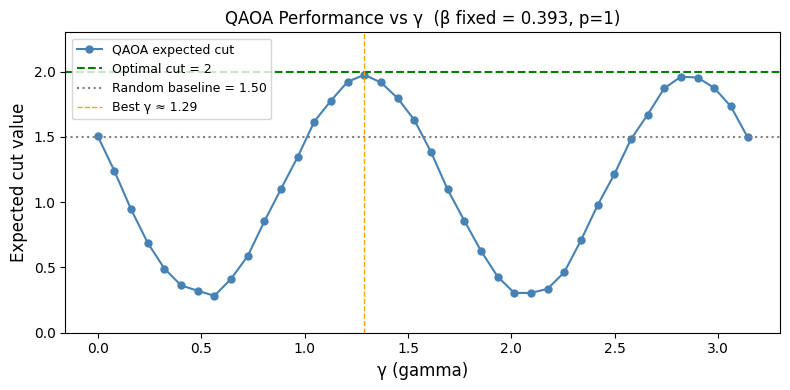

Peak expected cut value: 1.9746 at γ ≈ 1.2889


In [11]:
# ── Plot the gamma sweep ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(gamma_values, expected_cuts, 'o-', color='steelblue',
        markersize=5, linewidth=1.5, label='QAOA expected cut')
ax.axhline(y=2, color='green', linestyle='--', linewidth=1.5, label='Optimal cut = 2')
ax.axhline(y=random_cut, color='gray', linestyle=':', linewidth=1.5,
           label=f'Random baseline = {random_cut:.2f}')

best_gamma = gamma_values[np.argmax(expected_cuts)]
ax.axvline(x=best_gamma, color='orange', linestyle='--', linewidth=1,
           label=f'Best γ ≈ {best_gamma:.2f}')

ax.set_xlabel('γ (gamma)', fontsize=12)
ax.set_ylabel('Expected cut value', fontsize=12)
ax.set_title(f'QAOA Performance vs γ  (β fixed = {fixed_beta:.3f}, p=1)', fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(0, 2.3)
plt.tight_layout()
plt.show()

print(f"Peak expected cut value: {max(expected_cuts):.4f} at γ ≈ {best_gamma:.4f}")

**What this tells me:**

- The expected cut value **oscillates** with γ. This is characteristic of quantum interference. The phase accumulation from the cost unitary cycles through constructive and destructive interference patterns as γ changes.
- At p=1, we can't reach the optimal cut of 2.0 in expectation for a triangle (the approximation ratio is theoretically bounded), but we get meaningfully closer than random.

In full QAOA, you'd use a classical optimizer (like `scipy.optimize.minimize`) to find the (γ, β) pair that maximizes this curve automatically.

Bitstring frequency histogram after optimizing for gamma, we should expect to see the "good" bitstrings appear more frequently.


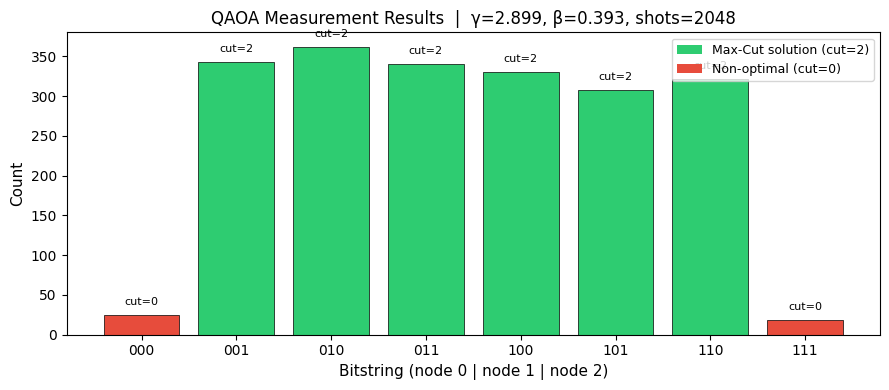

In [13]:
# ── Circuit using optimized gamma = 2.899, fixed beta, p=1 ───────────────────────────────────────────────────────

gamma=2.899
n_shots=2048
data= build_and_run_qaoa(gamma, fixed_beta, edges, n_nodes)

c = data[1]
# ── Bar chart of counts ───────────────────────────────────────────────────────
# Color bars: green if the bitstring is a Max-Cut solution (cut=2), red otherwise

all_bitstrings = [format(i, f'0{n_nodes}b') for i in range(2**n_nodes)]
freqs = [c.get(bs, 0) for bs in all_bitstrings]
colors = ['#2ecc71' if cut_value(bs, edges) == 2 else '#e74c3c'
          for bs in all_bitstrings]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(all_bitstrings, freqs, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Bitstring (node 0 | node 1 | node 2)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title(f'QAOA Measurement Results  |  γ={gamma:.3f}, β={beta:.3f}, shots={n_shots}',
             fontsize=12)

# Add cut-value annotations above each bar
for bar, bs in zip(bars, all_bitstrings):
    cv = cut_value(bs, edges)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'cut={cv}', ha='center', va='bottom', fontsize=8)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Max-Cut solution (cut=2)'),
                   Patch(facecolor='#e74c3c', label='Non-optimal (cut=0)')]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.show()

## Key Observations <a id="observations"></a>

I approached QAOA through the lens of classical optimization. Structurally, it resembles an optimization loop where parameters are updated to minimize an objective function. The key difference is that the objective is evaluated through a quantum circuit, making it a hybrid quantum-classical process. This became much clearer after implementation, especially in how parameter choices affected the measurement distribution.

The interaction between the cost and mixer layers was also more intuitive after building the circuit. Even in a simple example, the output distribution was highly sensitive to γ and β, reinforcing that parameter tuning plays a significant role in amplifying useful solutions.

**QAOA vs. Classical Optimization (e.g.Gradient Descent)**
| Step              | Gradient Descent  | QAOA                          |
| ----------------- | ----------------- | ----------------------------- |
| Define objective  | Loss function     | Cost Hamiltonian              |
| Initialize params | weights           | γ, β                          |
| Evaluate          | forward pass      | quantum circuit + measurement |
| Update            | gradients         | classical optimizer           |
| Iterate           | until convergence | until convergence             |


The structure is similar, but the problem space is different. Classical methods like gradient descent focus on continuous optimization (e.g., training models), while QAOA targets combinatorial optimization problems such as Max-Cut, scheduling, and routing. QAOA introduces a different way of exploring the solution space, but whether it provides a practical advantage depends on the problem.

I also found it interesting that QAOA operates on graph-structured problems in a way that initially reminded me of graph neural networks. Both use layered operations and local interactions across nodes. However, they serve different purposes: QAOA solves a discrete optimization problem, while GNNs learn representations.

More specifically, QAOA propagates information through edge-based interactions in the cost unitary, while GNNs use message passing to aggregate neighbor features. The structural similarity is there, but QAOA accumulates phase information to bias measurement outcomes, whereas GNNs optimize learned representations through training.

Due to this structural resemblance, researchers have explored using GNN-based models to predict good QAOA starting parameters, which reduces the number of circuit evaluations needed in the outer optimization loop. That connection made my  analogy feel less like a coincidence and more like a structural property worth understanding.

## Where I Got Stuck (and What Clicked) <a id="where-i-got-stuck"></a>

Before jumping fully into QAOA, I spent some time filling in a few computing fundamentals I wasn’t deeply familiar with. I revisited concepts like Turing machines to better understand what simulators are actually doing, and I wanted a more practical sense of what NP-hard means. The way I’ve simplified it is that these problems scale poorly as the system grows, which helped me understand why alternative approaches like quantum are even being explored.

Where I actually got stuck was less on the algorithm itself and more on the tooling. I started with IBM’s Qiskit quickstart, but it abstracts away a lot of the underlying mechanics. That pushed me to rebuild the circuit manually so I could see how the gates map to the algorithm instead of relying on the library to handle it.

The main friction points were:

**Backends**

It wasn’t immediately obvious why a QuantumCircuit doesn’t just run. The shift that helped was realizing the circuit is just a description of operations, and the backend is what actually executes it. The analogy that clicked for me was from simulation: the circuit is the model or mesh, and the backend is the solver. Once I thought about it that way, the separation made sense.

**Primitives (Sampler / Estimator)**

My current understanding is that these are higher-level interfaces for getting results out of a circuit. Sampler returns probability distributions, and Estimator returns expectation values. They’re called primitives because they represent the most basic outputs of a quantum computation. I avoided using them here to keep the mechanics visible, but I can see how they would simplify workflows, especially when running on real hardware.

**Bit Ordering**

Qiskit’s bit ordering took a minute to get used to. It doesn’t line up with how I naturally read binary, and that can quietly introduce errors if you’re not paying attention. Once I understood how qubit indices map to measurement outputs, it became manageable.

**Phase vs. Probability**

This didn’t fully click until I ran the circuit. The cost unitary applies phase but doesn’t change measurement probabilities on its own. When I removed the mixer, the distribution stayed flat, which made it obvious. The mixer is what turns those phase differences into something observable. They only work as a pair, and that wasn’t obvious to me from reading alone.

**Mixer Choice**

I also started to see that the choice of mixer depends on the problem. The standard Rx mixer works for unconstrained problems like Max-Cut because it allows transitions across the full solution space. For constrained problems, you’d need something more specialized to stay within valid states. This felt very similar to choosing a solver in simulation, where a general-purpose method works broadly, but more specific formulations are needed when constraints matter.

---
## Next Steps <a id="next-steps"></a>

To go deeper from here, I would try the following:

1. **Add a classical optimizer.** Replace the manual γ sweep with `scipy.optimize.minimize('COBYLA', ...)` to automatically find the best (γ, β) pair. This is the full QAOA outer loop.

2. **Increase p.** Try p=2 or p=3 by repeating the U_C and U_B layers with separate parameters (γ₁, γ₂, ..., β₁, β₂, ...).

3. **Try a larger graph.** A 4-node cycle or a 5-node graph will still run fast on a simulator but has a richer solution space.

4. **Use the Qiskit Sampler primitive.** Refactor the `simulator.run(...)` call to use `StatevectorSampler` from `qiskit.primitives`. This is required for running on real hardware.

5. **Add noise.** Use `AerSimulator` with a fake noise model (e.g., `FakeManhattan`) to simulate what happens on real hardware. See how much the expected cut value degrades.

6. **Implement VQE for comparison.** The Variational Quantum Eigensolver is QAOA's cousin. It uses a more general ansatz and the Estimator primitive. Understanding both clarifies when to use each.

7. **Explore QAOA warm-starting.** [Research papers](https://arxiv.org/pdf/2111.03016) have shown that initializing QAOA parameters using predictions from a GNN trained on similar graphs can dramatically reduce the number of circuit evaluations needed. This is where the GNN connection becomes practically useful.